<a href="https://colab.research.google.com/github/MankotiaGit/Statistical-Foundation-of-Data-Sciences-/blob/main/SFDS_PRACTICAL_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1: Import data handling packages

Step 2: Import hypothesis testing modules

Step 3: Define the dataset endpoint

Step 4: Load the remote dataset into a DataFrame

Step 5: Inspect columns and records

Step 6: Segment evaluation ratings by gender

Step 7: Compute sample sizes and summary statistics for gender groups

Step 8: Execute Welch's independent two-sample t-test

Step 9: Bin the continuous age variable into categories

Step 10: Verify age category distributions

Step 11: Specify and fit the Ordinary Least Squares (OLS) model

Step 12: Generate the One-Way ANOVA summary table

Step 13: Build a two-way contingency table for categorical variables

Step 14: Execute the Chi-Square test of independence

Step 15: Extract continuous arrays for correlation analysis

Step 16: Compute the Pearson correlation coefficient


Step 17: Set the statistical decision threshold ($\alpha = 0.05$)

Step 18: Evaluate null hypotheses and print decisions








In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [3]:
url = "https://vincentarelbundock.github.io/Rdatasets/csv/AER/TeachingRatings.csv"
df = pd.read_csv(url)

In [4]:
print("Dataset loaded successfully. First 3 rows:")
print(df.head(3))
print("=" * 70)

Dataset loaded successfully. First 3 rows:
   rownames minority  age  gender credits    beauty  eval division native  \
0         1      yes   36  female    more  0.289916   4.3    upper    yes   
1         2       no   59    male    more -0.737732   4.5    upper    yes   
2         3       no   51    male    more -0.571984   3.7    upper    yes   

  tenure  students  allstudents  prof  
0    yes        24           43     1  
1    yes        17           20     2  
2    yes        55           55     3  


(Q1)

In [5]:
print("\n--- Q1: T-Test (Evaluation Score by Gender) ---")
male_eval = df[df['gender'] == 'male']['eval']
female_eval = df[df['gender'] == 'female']['eval']


--- Q1: T-Test (Evaluation Score by Gender) ---


I'm printing out a section header for a T-test and then I'm splitting the evaluation scores into two separate groups—one for male instructors and one for female instructors—so I can compare them.

In [6]:
t_stat, t_pval = stats.ttest_ind(male_eval, female_eval, equal_var=False)

print(f"Male Mean Eval: {male_eval.mean():.4f} (SD: {male_eval.std():.4f}, n={len(male_eval)})")
print(f"Female Mean Eval: {female_eval.mean():.4f} (SD: {female_eval.std():.4f}, n={len(female_eval)})")
print(f"T-statistic: {t_stat:.4f}, p-value: {t_pval:.4e}")

if t_pval < 0.05:
    print("Conclusion: Reject H0. Gender has a statistically significant effect on teaching evaluations (alpha = 0.05).")
else:
    print("Conclusion: Fail to reject H0. No statistically significant difference between genders.")
print("=" * 70)

Male Mean Eval: 4.0690 (SD: 0.5567, n=268)
Female Mean Eval: 3.9010 (SD: 0.5388, n=195)
T-statistic: 3.2667, p-value: 1.1761e-03
Conclusion: Reject H0. Gender has a statistically significant effect on teaching evaluations (alpha = 0.05).


I'm running Welch's independent t-test to compare the evaluation scores of male and female instructors without assuming equal variances.

Then, I'm printing out the descriptive statistics—including the mean standard deviation and sample size for both groups—along with the resulting T-statistic and p-value.

Finally, I'm comparing the p-value against an alpha level of 0.05 to decide whether to reject or fail to reject the null hypothesis printing out my final conclusion and adding a separator line at the end.

(Q2)

In [7]:
print("\n--- Q2: One-Way ANOVA (Beauty Score across Age Groups) ---")


--- Q2: One-Way ANOVA (Beauty Score across Age Groups) ---


In [8]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 40, 57, 100],
    labels=['<=40 years', '41-57 years', '>57 years']
)

I'm creating a new column called "age_group" by dividing the continuous instructor ages into specific categories—40 years or younger between 41 and 57 years and older than 57 years—using pandas' cut function.

In [9]:
model = ols('beauty ~ C(age_group)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print("Age Group Counts:")
print(df['age_group'].value_counts())
print("\nANOVA Table:")
print(anova_table)

f_stat = anova_table.loc['C(age_group)', 'F']
anova_pval = anova_table.loc['C(age_group)', 'PR(>F)']
print(f"\nF-statistic: {f_stat:.4f}, p-value: {anova_pval:.4e}")

if anova_pval < 0.05:
    print("Conclusion: Reject H0. Beauty score differs significantly across age groups (alpha = 0.05).")
else:
    print("Conclusion: Fail to reject H0. No significant difference in beauty score across age groups.")
print("=" * 70)

Age Group Counts:
age_group
41-57 years    256
<=40 years     113
>57 years       94
Name: count, dtype: int64

ANOVA Table:
                  sum_sq     df          F        PR(>F)
C(age_group)   18.964684    2.0  16.252422  1.513160e-07
Residual      268.383213  460.0        NaN           NaN

F-statistic: 16.2524, p-value: 1.5132e-07
Conclusion: Reject H0. Beauty score differs significantly across age groups (alpha = 0.05).


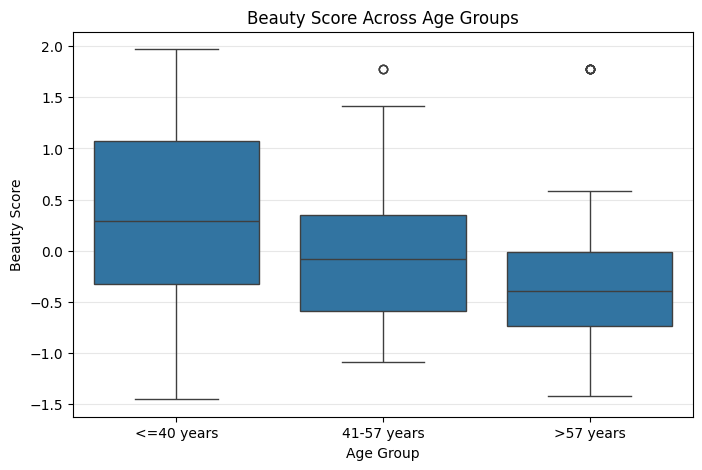

In [10]:
# Graph: Beauty score across age groups

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.boxplot(
    x='age_group',
    y='beauty',
    data=df
)

plt.title('Beauty Score Across Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Beauty Score')
plt.grid(axis='y', alpha=0.3)

plt.show()

I'm fitting an ordinary least squares regression model to examine the relationship between beauty scores and the different age groups and then generating a Type II ANOVA table from that model.

Next, I'm printing out the sample counts for each age group and displaying the full ANOVA table.

After that I'm extracting the F-statistic and p-value to check for statistical significance comparing the p-value against an alpha level of 0.05 to decide whether to reject the null hypothesis printing my final conclusion and adding a separator line at the end.

(Q3)

In [11]:
print("\n--- Q3: Chi-Square Test (Tenure vs. Gender) ---")
contingency_table = pd.crosstab(df['tenure'], df['gender'])
print("Contingency Table (Observed Frequencies):")
print(contingency_table)

chi2_stat, chi2_pval, dof, expected = stats.chi2_contingency(contingency_table)
print(f"\nChi-Square Statistic: {chi2_stat:.4f}")
print(f"Degrees of Freedom: {dof}")
print(f"p-value: {chi2_pval:.4e}")

if chi2_pval < 0.05:
    print("Conclusion: Reject H0. There is a statistically significant association between tenure and gender.")
else:
    print("Conclusion: Fail to reject H0. There is no significant association between tenure and gender.")
print("=" * 70)


--- Q3: Chi-Square Test (Tenure vs. Gender) ---
Contingency Table (Observed Frequencies):
gender  female  male
tenure              
no          50    52
yes        145   216

Chi-Square Statistic: 2.2068
Degrees of Freedom: 1
p-value: 1.3741e-01
Conclusion: Fail to reject H0. There is no significant association between tenure and gender.


I'm printing out a section header for a Chi-Square test and creating a contingency table to check the observed frequencies between tenure and gender.

Then I'm running the Chi-Square test of independence to calculate the test statistic degrees of freedom and p-value printing those results out and comparing the p-value against an alpha level of 0.05 to draw my final conclusion before finishing with a separator line.

(Q4)

In [12]:
print("\n--- Q4: Pearson Correlation (Evaluation Score vs. Beauty Score) ---")
corr_coeff, corr_pval = stats.pearsonr(df['eval'], df['beauty'])

print(f"Pearson Correlation Coefficient (r): {corr_coeff:.4f}")
print(f"p-value: {corr_pval:.4e}")

if corr_pval < 0.05:
    print(f"Conclusion: Reject H0. There is a statistically significant positive correlation (r = {corr_coeff:.4f}) between beauty and teaching evaluation scores.")
else:
    print("Conclusion: Fail to reject H0. No significant correlation found.")
print("=" * 70)


--- Q4: Pearson Correlation (Evaluation Score vs. Beauty Score) ---
Pearson Correlation Coefficient (r): 0.1890
p-value: 4.2471e-05
Conclusion: Reject H0. There is a statistically significant positive correlation (r = 0.1890) between beauty and teaching evaluation scores.


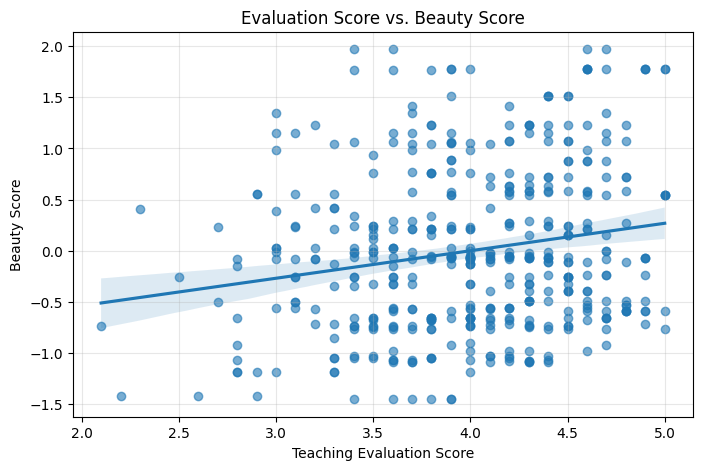

In [13]:
# Graph: Evaluation Score vs Beauty Score

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.regplot(
    x='eval',
    y='beauty',
    data=df,
    scatter_kws={'alpha': 0.6},
    line_kws={}
)

plt.title('Evaluation Score vs. Beauty Score')
plt.xlabel('Teaching Evaluation Score')
plt.ylabel('Beauty Score')
plt.grid(alpha=0.3)

plt.show()

I'm printing out a section header for a Pearson correlation test and then calculating the correlation coefficient and p-value between teaching evaluation scores and beauty scores.

After that I'm printing out the results and comparing the p-value against an alpha level of 0.05 to draw my final conclusion before finishing with a separator line.